# Dumbbell Chart

A dumbbell chart shows two values per category, a dot at each and a connector between them, so the reader sees the change from one state to the other (before and after, one year and a later one) or the gap between two groups, and how that change or gap compares across the categories. This guide shows how to create dumbbell charts with the [datachart.charts.DumbbellChart](../../../references/charts/dumbbellchart/#datachart.charts.DumbbellChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-dumbbell-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import DumbbellChart

## Basics

The examples in this guide share one dataset: life expectancy at birth in twelve countries in 2000 and in 2019, the last year before the COVID-19 pandemic, in years (source: the World Health Organization's Global Health Observatory, indicator WHOSIS_000001, 2024 release, rounded to one decimal). The data lives in a hidden cell. `life` holds one record per country for both sexes together, `women` and `men` hold the same records per sex, and `recent` runs from 2019 to 2021, across the pandemic. Two decades of gains, a gap between women and men that is closing in some countries and opening in others, and a pandemic that undid part of the progress: the customizations below help to read each of these.

In [2]:
# life expectancy at birth in years, 2000 and 2019 (WHO Global Health Observatory, rounded)
LIFE = {
    # country: (both sexes 2000, 2019), (women 2000, 2019), (men 2000, 2019)
    "Japan": ((81.5, 84.5), (84.8, 87.2), (78.1, 81.7)),
    "Switzerland": ((79.7, 83.5), (82.3, 85.1), (76.9, 81.8)),
    "Norway": ((78.5, 82.7), (81.2, 84.2), (75.9, 81.1)),
    "Slovenia": ((76.1, 81.3), (79.7, 84.0), (72.2, 78.6)),
    "Germany": ((78.1, 81.0), (80.9, 83.2), (75.0, 78.7)),
    "United States": ((76.7, 78.7), (79.1, 81.0), (74.2, 76.5)),
    "China": ((70.8, 77.3), (73.3, 80.4), (68.6, 74.6)),
    "Brazil": ((71.5, 75.5), (75.0, 78.7), (68.2, 72.2)),
    "Russia": ((65.2, 73.2), (72.1, 78.0), (58.8, 68.2)),
    "India": ((63.2, 70.7), (64.3, 72.4), (62.2, 69.2)),
    "South Africa": ((57.1, 65.8), (59.6, 68.8), (54.2, 62.5)),
    "Nigeria": ((54.1, 63.1), (55.4, 64.5), (52.8, 61.7)),
}
# the global life expectancy at birth in 2019 (WHO Global Health Observatory)
WORLD_2019 = 73.1


def records(column):
    return [
        {"label": country, "start": values[column][0], "end": values[column][1]}
        for country, values in LIFE.items()
    ]


life, women, men = records(0), records(1), records(2)

# both sexes, 2019 and 2021 (WHO Global Health Observatory, rounded)
RECENT = {
    "Japan": (84.5, 84.5),
    "Switzerland": (83.5, 83.3),
    "Norway": (82.7, 82.9),
    "Slovenia": (81.3, 80.4),
    "Germany": (81.0, 80.5),
    "United States": (78.7, 76.4),
    "China": (77.3, 77.6),
    "Brazil": (75.5, 72.4),
    "Russia": (73.2, 70.0),
    "India": (70.7, 67.3),
    "South Africa": (65.8, 61.5),
    "Nigeria": (63.1, 63.4),
}
recent = [{"label": c, "start": s, "end": e} for c, (s, e) in RECENT.items()]

Each record is a dictionary with a `label` (the category), a `start` value and an `end` value; here the value in 2000 and the value in 2019:

In [3]:
life[:3]

[{'label': 'Japan', 'start': 81.5, 'end': 84.5},
 {'label': 'Switzerland', 'start': 79.7, 'end': 83.5},
 {'label': 'Norway', 'start': 78.5, 'end': 82.7}]

**Basic example.** Only the `data` argument is required. Every record is one row, the first at the top: a dot at its start, a dot at its end, and a connector between them. Every country gained, and the length of each connector is the gain:

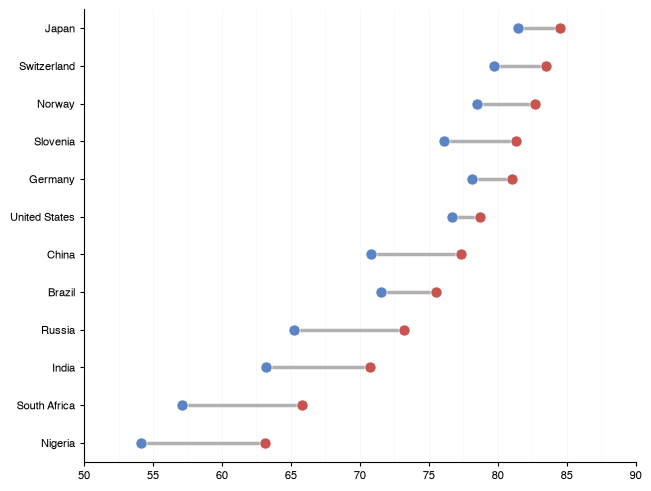

In [4]:
DumbbellChart(
    # add the data to the chart
    data=life
).show()

## Customizing the Dumbbell Chart

Every customization is either a keyword argument of `DumbbellChart` or a `plot_dumbbell_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                     | Use                                                                 | See |
| :--------------------------------------------- | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                    | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| rotate the tick labels                         | `xtickrotate`, `ytickrotate`                                        | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range                             | `xmin`, `xmax`, `ymin`, `ymax`                                      | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                              | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| change the grid lines                          | `show_grid`, `style={"plot_dumbbell_grid_minor": ...}`              | [Figure size and grid](#figure-size-and-grid) |
| run the values up the page                     | `orientation`                                                       | [Orientation](#orientation) |
| order the categories by start, end, or change  | `sort`, `sort_by`                                                   | [Category order](#category-order) |
| name the two endpoints in a legend             | `start_name`, `end_name`, `show_legend`, `legend`                   | [Endpoint names and legend](#endpoint-names-and-legend) |
| print the endpoint values or the change        | `show_values`, `value_format`                                       | [Value labels](#value-labels) |
| show whether each value rose or fell           | `show_direction`                                                    | [Rises and falls](#rises-and-falls) |
| tell the endpoints apart by shape              | `marker`                                                            | [Markers and connectors](#markers-and-connectors) |
| dash the connectors                            | `connector_style`                                                   | [Markers and connectors](#markers-and-connectors) |
| change the dot and connector colors and sizes  | `style={"plot_dumbbell_start_color": ..., ...}`                     | [Dumbbell style](#dumbbell-style) |
| highlight some categories, mute the rest       | `emphasis_rule`, the `"emphasis"` key of a record                   | [Emphasis](#emphasis) |
| mark a reference value                         | `vlines`, `hlines`, `dlines`                                       | [Reference lines and bands](#reference-lines-and-bands) |
| shade a range of values                        | `vspans`, `hspans`                                                  | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                        | `texts`                                                             | [Text annotations](#text-annotations) |
| compare several groups on the same categories  | `data` as a list of lists, `subtitle`                               | [Multiple Dumbbell Charts](#multiple-dumbbell-charts) |
| highlight one group, mute the rest             | `emphasis`                                                          | [Multiple Dumbbell Charts](#multiple-dumbbell-charts) |
| draw each group in its own subplot             | `subplots`, `sharex`, `sharey`, `max_cols`                          | [Subplots](#subplots) |
| combine with other charts                      | `Panel`, `Grid`                                                     | [Composing dumbbell charts](#composing-dumbbell-charts) |
| use a logarithmic value axis                   | `scaley`                                                            | [Axis scales](#axis-scales) |
| restyle every chart at once                    | `config.set_theme`                                                  | [Themes](#themes) |
| save the chart to a file                       | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `value_kind` | [`DUMBBELL_VALUE`](../../../references/constants/#datachart.constants.DUMBBELL_VALUE) |
| `sort_by` | [`DUMBBELL_SORT_KEY`](../../../references/constants/#datachart.constants.DUMBBELL_SORT_KEY) |
| `marker` | [`LINE_MARKER`](../../../references/constants/#datachart.constants.LINE_MARKER) |
| `connector_style` | [`LINE_STYLE`](../../../references/constants/#datachart.constants.LINE_STYLE) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |

The full list of style attributes is in the [datachart.typings.DumbbellStyleAttrs](../../../references/charts/dumbbellchart/#datachart.typings.DumbbellStyleAttrs) type; the full list of parameters is in the [datachart.charts.DumbbellChart](../../../references/charts/dumbbellchart/#datachart.charts.DumbbellChart) reference.

### Title, axis labels and ticks

Without a title and axis labels the reader cannot tell what the two dots stand for; `title`, `xlabel` and `ylabel` say it. The axis arguments are spatial: in the default horizontal chart `xlabel` names the value axis and `ylabel` the category axis. `xtickrotate` and `ytickrotate` tilt the tick labels when they crowd each other, which country names on the vertical axis do not need. `xmin`, `xmax`, `ymin` and `ymax` fix the axis range: a dumbbell encodes value by position, not by length, so the value axis need not start at zero, and a tighter range spreads the dots out.

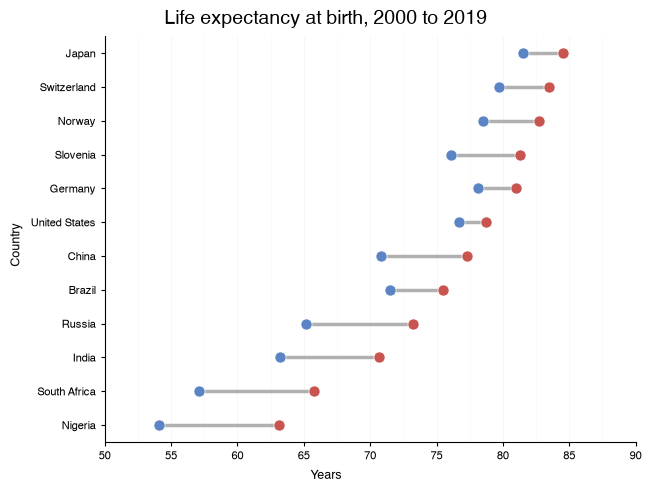

In [5]:
DumbbellChart(
    data=life,
    # add the title
    title="Life expectancy at birth, 2000 to 2019",
    # add the x and y axis labels
    xlabel="Years",
    ylabel="Country",
    # fix the value axis range
    xmin=50,
    xmax=90,
).show()

### Figure size and grid

Twelve rows need height, and a chart with a few rows should not get it. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width.

The grid lines let the eye carry a dot across to the value axis. By default they follow the values, whichever way the chart runs, with fainter lines halfway between the labelled values so a value reads off quickly; the `plot_dumbbell_grid_minor` style attribute sets how many parts each step splits into (`0` draws no fainter lines). An explicit `show_grid`, a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member, names the axes literally (`SHOW_GRID.X`, `SHOW_GRID.Y` or `SHOW_GRID.BOTH`). The example keeps the vertical value grid and drops the fainter lines.

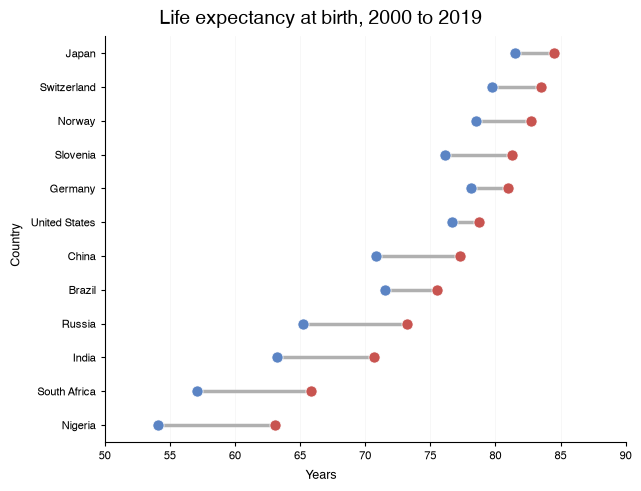

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

DumbbellChart(
    data=life,
    title="Life expectancy at birth, 2000 to 2019",
    xlabel="Years",
    ylabel="Country",
    # a full-width, medium-height figure
    figsize=FIG_SIZE.FULL_MEDIUM,
    # grid lines along the value axis, without the fainter lines in between
    show_grid=SHOW_GRID.X,
    style={"plot_dumbbell_grid_minor": 0},
).show()

### Orientation

Rows suit a long list of names, but a change reads naturally as a rise or a fall, and for that the values should run up the page. `orientation=ORIENTATION.VERTICAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) draws one column per category, the first at the left, so the end dot of a gain sits above its start dot. The axis labels, the grid and the axis limits swap with it; `xtickrotate` turns the country names out of each other's way.

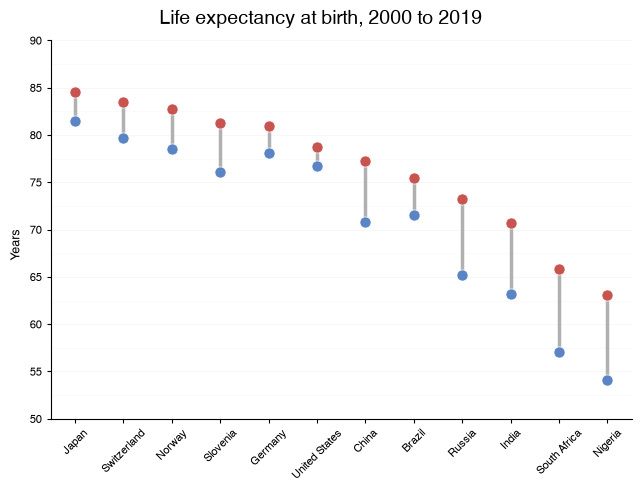

In [7]:
from datachart.constants import ORIENTATION

DumbbellChart(
    data=life,
    title="Life expectancy at birth, 2000 to 2019",
    # the axis labels swap with the orientation
    ylabel="Years",
    # run the values up the page
    orientation=ORIENTATION.VERTICAL,
    xtickrotate=45,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Category order

The input order ranks the countries by their life expectancy in 2000, which is one story; ranking them by how much they gained is another. `sort` orders the categories ([SORT](../../../references/constants/#datachart.constants.SORT)): `SORT.DESCENDING` puts the largest first, `SORT.ASCENDING` the smallest, `None` keeps the input order. `sort_by` names the key ([DUMBBELL_SORT_KEY](../../../references/constants/#datachart.constants.DUMBBELL_SORT_KEY)): `START` (the default), `END`, or `DELTA`, the change `end - start`. Ties keep the input order, and `sort_by` needs a `sort` to act on. Ordered by the gain, the ranking flips: the countries that started lowest gained the most, Nigeria nine years, while the United States gained two.

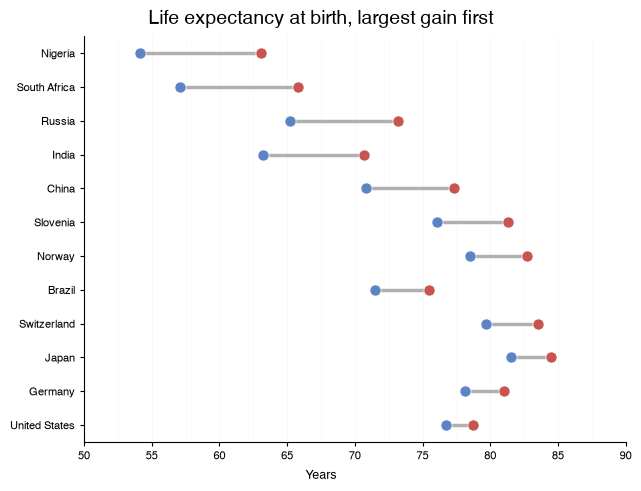

In [8]:
from datachart.constants import SORT, DUMBBELL_SORT_KEY

DumbbellChart(
    data=life,
    title="Life expectancy at birth, largest gain first",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # order the countries by their change, the largest first
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
).show()

### Endpoint names and legend

Two colors of dot mean nothing until the legend says which is which. `start_name` and `end_name` name the endpoints, each gets one legend entry, and the legend switches on as soon as a name is given (`show_legend=False` hides it again). `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The top rows of this chart reach the right edge, so the legend goes outside the axes.

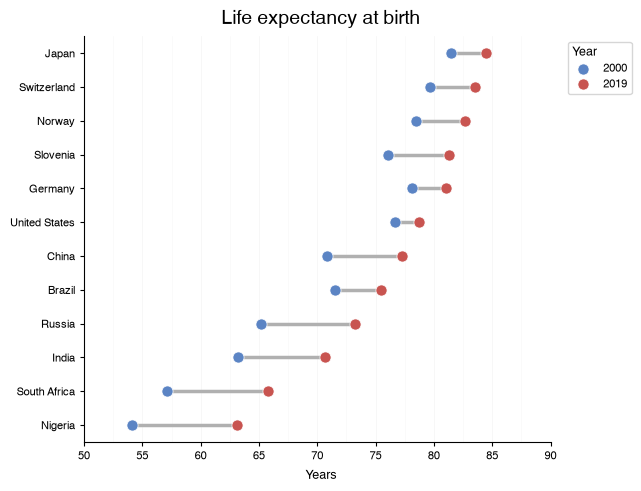

In [9]:
from datachart.constants import LEGEND_LOCATION

DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # name the endpoints; the legend switches on with them
    start_name="2000",
    end_name="2019",
    # a titled legend outside the axes, to the right
    legend={"title": "Year", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Value labels

When the exact numbers matter, `show_values=True` prints them and `value_kind` picks which ([DUMBBELL_VALUE](../../../references/constants/#datachart.constants.DUMBBELL_VALUE)): `ENDPOINTS`, the default, prints each endpoint's value past its dot, on the side away from the connector, and `DELTA` prints the change `end - start` at the connector midpoint. `value_format` formats the numbers: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:+.1f}"` or `"%g"` style string, and the label font size, color and padding are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)). Endpoint labels answer *what were the values*; the value axis is widened a little so the outer labels have room.

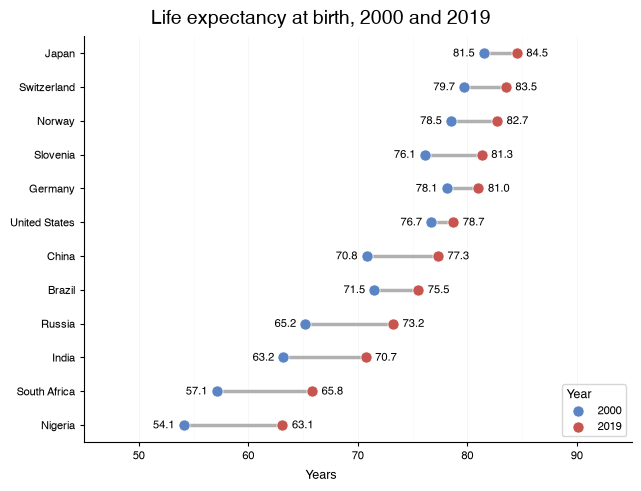

In [10]:
from datachart.constants import DUMBBELL_VALUE

DumbbellChart(
    data=life,
    title="Life expectancy at birth, 2000 and 2019",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    # print both endpoint values, with one decimal
    show_values=True, value_kind=DUMBBELL_VALUE.ENDPOINTS,
    value_format="{:.1f}",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    # room for the labels on both sides
    xmin=45,
    xmax=95,
).show()

Delta labels answer *how much did it change*, and a signed format (`"{:+.1f}"`) keeps a gain and a loss apart at a glance. Sorted by the change, the labels turn the chart into a ranked table of gains:

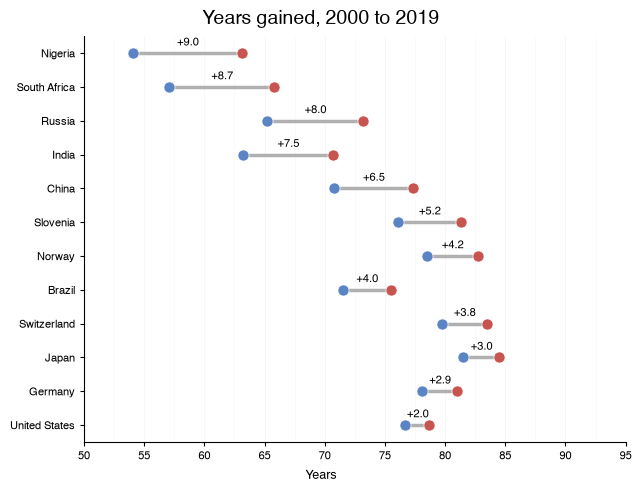

In [11]:
DumbbellChart(
    data=life,
    title="Years gained, 2000 to 2019",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    # print the signed change at every connector
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
).show()

### Rises and falls

A value that fell has its end dot on the other side of its start dot, and when some rows rise while others fall, the color of the dots is a slow way to tell them apart. `show_direction=True` draws a thin arrow beside each connector from the start to the end: above a horizontal dumbbell, right of a vertical one, with the delta label moving out past it. The `plot_dumbbell_arrow_*` style attributes set its look. From 2019 to 2021, across the pandemic, life expectancy fell in most of these countries, by more than three years in Brazil, Russia, India and South Africa, rose a little in Norway, China and Nigeria, and held in Japan, whose record draws a single dot and no arrow.

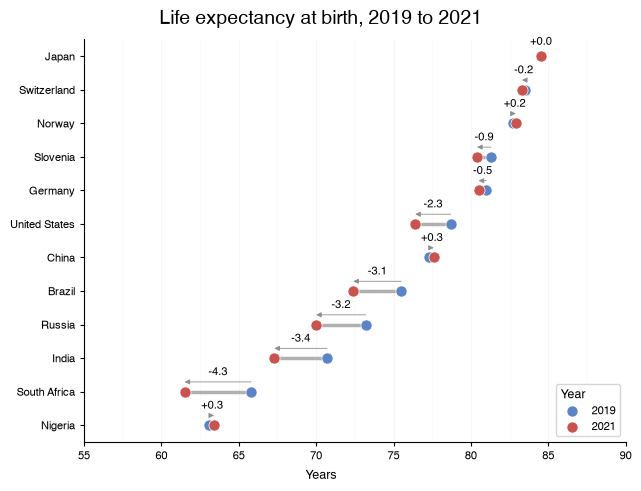

In [12]:
DumbbellChart(
    data=recent,
    title="Life expectancy at birth, 2019 to 2021",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2019",
    end_name="2021",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    # an arrow beside every connector, from start to end
    show_direction=True,
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
    xmin=55,
    xmax=90,
).show()

### Markers and connectors

A chart that will be printed in greyscale loses the color of the dots, and then the shape has to tell the endpoints apart. `marker` takes a `(start, end)` pair of [LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER) members, and `connector_style` sets the line style of the connectors with a [LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) member. Both replace the theme's choice; a chart's `style` dictionary still wins over them.

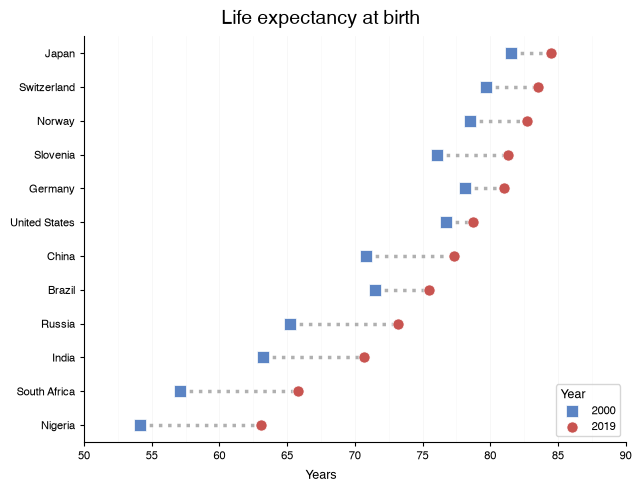

In [13]:
from datachart.constants import LINE_MARKER, LINE_STYLE

DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    # a square for the start, a circle for the end
    marker=(LINE_MARKER.SQUARE, LINE_MARKER.CIRCLE),
    # dotted connectors
    connector_style=LINE_STYLE.DOTTED,
).show()

### Dumbbell style

The `style` dictionary sets the look of the dots and the connectors: the two endpoint colors, the dot size and alpha, the markers and edges, the connector color, width and style, and the direction arrows; the attributes are listed in [datachart.typings.DumbbellStyleAttrs](../../../references/charts/dumbbellchart/#datachart.typings.DumbbellStyleAttrs), and any attribute left out keeps the value of the active theme. A muted start and a saturated end put the weight on where each country ended up, and a wider connector in a lighter shade makes the gain read as a bar between the two:

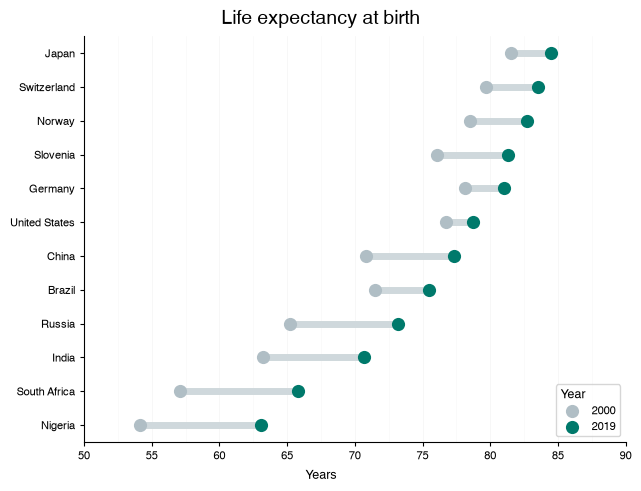

In [14]:
DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    # a muted start, a saturated end, and a wide light connector
    style={
        "plot_dumbbell_start_color": "#b0bec5",
        "plot_dumbbell_end_color": "#00796b",
        "plot_dumbbell_size": 90,
        "plot_dumbbell_edge_width": 0,
        "plot_dumbbell_connector_color": "#cfd8dc",
        "plot_dumbbell_connector_width": 5,
    },
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. A record can carry its own `"emphasis"` key: `"highlight"` rims the dots in the text color and thickens the connector, `"background"` mutes the dots and the connector in the theme's muted color and drops their labels. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Asking only about Slovenia is a matter of tagging one record and muting the rest:

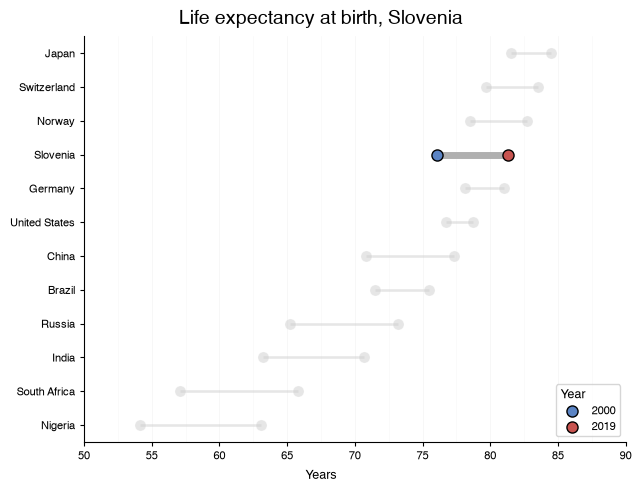

In [15]:
# tag Slovenia, mute the rest
slovenia_marked = [
    {**record, "emphasis": "highlight" if record["label"] == "Slovenia" else "background"}
    for record in life
]

DumbbellChart(
    data=slovenia_marked,
    title="Life expectancy at birth, Slovenia",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
).show()

`emphasis_rule` picks the records from the data instead of tagging them by hand. It is a one-key dictionary read against each record's change `end - start`: `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive); the records that match are highlighted, the rest muted, and a record's own `"emphasis"` key wins over the rule. With the delta labels, the three largest gains stand out and keep their labels while the muted rows drop theirs:

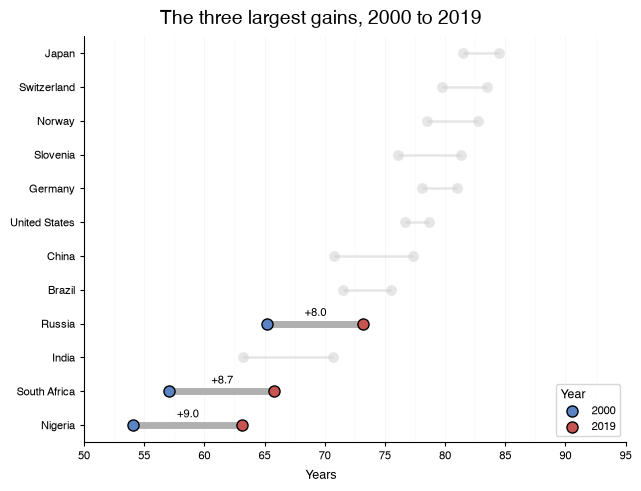

In [16]:
DumbbellChart(
    data=life,
    title="The three largest gains, 2000 to 2019",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    # highlight the three largest changes, mute the rest
    emphasis_rule={"top": 3},
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
).show()

### Reference lines and bands

A reference value puts the rows in context: where does the world stand, which rows have crossed a threshold. In the default horizontal chart a value is marked with `vlines` (a vertical line at a value) and a range shaded with `vspans`; `hlines` and `hspans` take positions along the category axis, which are row positions (`0` for the first row, `1` for the second, …), so a half-integer sits between two rows; a vertical chart swaps the pairs. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs). The example marks the global life expectancy of 2019 with a dotted line and shades the band above 80 years, which five countries had reached by 2019 and only Japan had in 2000.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). The rows sit at `0`, `1`, `2`, … down the category axis, so a diagonal asks whether the ranking declines evenly: the line runs from the top row's 2019 value to the bottom row's, and a row left of it has fallen behind that pace.

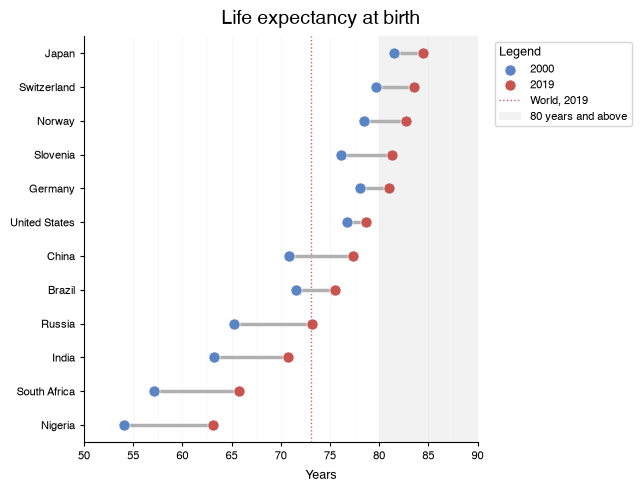

In [17]:
DumbbellChart(
    data=life,
    # a dotted line at the global value of 2019
    vlines={
        "x": WORLD_2019,
        "label": "World, 2019",
        "style": {"plot_vline_color": "#c1121f", "plot_vline_style": LINE_STYLE.DOTTED},
    },
    # shade the band above 80 years
    vspans={"xmin": 80, "xmax": 90, "label": "80 years and above"},
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    xmin=50,
    xmax=90,
).show()

In [ ]:
ends = [record["end"] for record in life]
# an even decline down the ranking: rows per year of life expectancy
rows_per_year = (len(ends) - 1) / (ends[-1] - ends[0])

DumbbellChart(
    data=life,
    # the line the rows would sit on if the ranking declined evenly
    dlines={
        "slope": rows_per_year,
        "intercept": -rows_per_year * ends[0],
        "label": "even decline down the ranking",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="Life expectancy at birth against an even decline",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    show_legend=True,
    xmin=50,
    xmax=90,
).show()

### Text annotations

Where a reference line marks a value, a note explains a row. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (value and row position in a horizontal chart, the first row at `0`) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The note below points at Russia's start dot and explains the largest gain among the European countries.

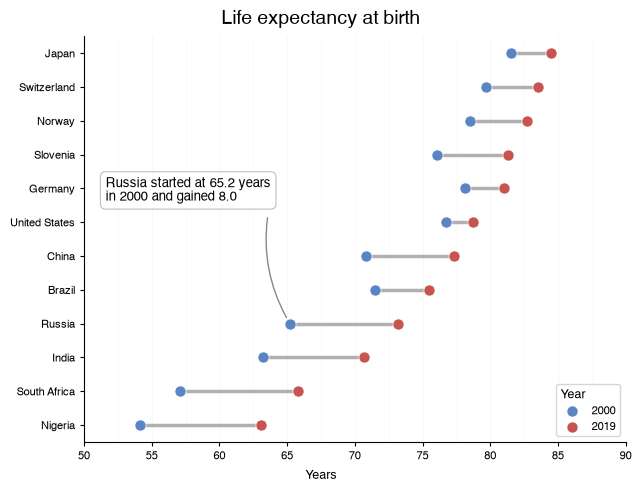

In [18]:
# row positions start at 0
RUSSIA = [record["label"] for record in life].index("Russia")

DumbbellChart(
    data=life,
    # a note pinned to the axes, pointing at Russia's start dot
    texts={
        "text": "Russia started at 65.2 years\nin 2000 and gained 8.0",
        "x": 0.04,
        "y": 0.62,
        "coords": "axes",
        "target": (LIFE["Russia"][0][0], RUSSIA),
    },
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
    xmin=50,
    xmax=90,
).show()

## Multiple Dumbbell Charts

To compare several groups on the same categories, pass a list of lists to `data`: each inner list is one chart, and the per-chart attributes (`subtitle`, `style`, `emphasis`) become lists aligned with it. The charts share one category axis (a category any chart lists gets a row) and overlay at its center, each in its own palette color, the end dot in the color and the start dot in a lighter shade of it. With `subtitle` and the endpoint names, the legend reads *subtitle (name)* per endpoint. `women` and `men` overlaid show the two changes side by side in each country, and the gap between them:

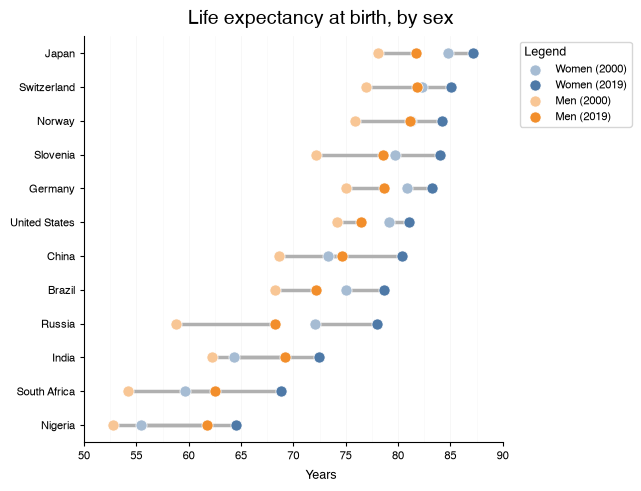

In [19]:
DumbbellChart(
    # one chart per sex, overlaid on the same rows
    data=[women, men],
    # named for the legend
    subtitle=["Women", "Men"],
    start_name="2000",
    end_name="2019",
    title="Life expectancy at birth, by sex",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

When the question is about one of the groups, `emphasis` takes one role per chart, aligned with `data` like `subtitle` and `style`: `"highlight"` bolds a chart, `"background"` mutes it and drops it from the legend, `None` leaves it as it is. Asking about men turns the women's rows into context, and it shows that men in Russia, Switzerland and Norway gained almost twice as many years as women:

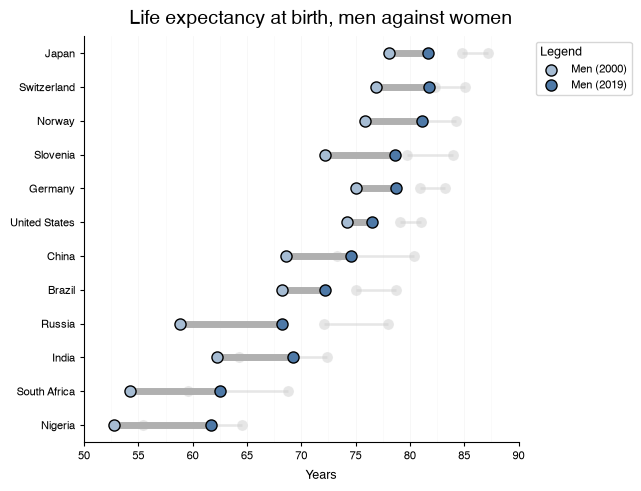

In [20]:
DumbbellChart(
    data=[women, men],
    subtitle=["Women", "Men"],
    start_name="2000",
    end_name="2019",
    # men are the question, women the context
    emphasis=["background", "highlight"],
    title="Life expectancy at birth, men against women",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Subplots

When the overlay gets crowded, or the question is about the shape of each group rather than the gap between them, `subplots=True` draws each chart in its own panel. `subtitle` titles the panels; `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the panels per row. `sharex=True` puts the panels on one value axis, so a dot in one panel is comparable with a dot in the next; without it each panel scales to its own range and the men's shorter lives would look as long as the women's. `sharey=True` keeps one category axis for all of them, so the country names print once and each country sits on the same row in every panel:

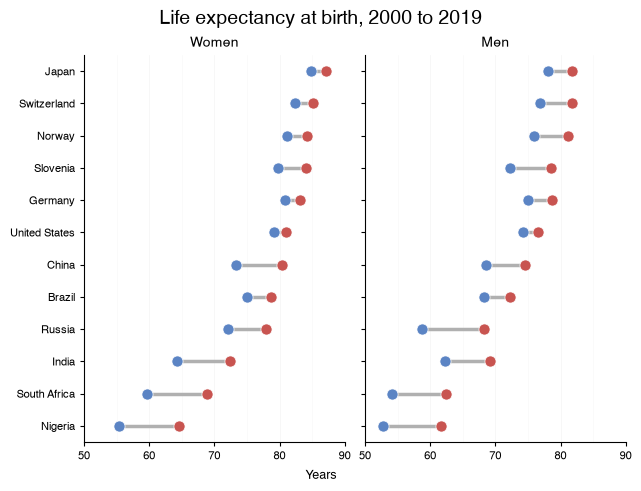

In [21]:
DumbbellChart(
    data=[women, men],
    subtitle=["Women", "Men"],
    title="Life expectancy at birth, 2000 to 2019",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # one panel per sex, on one value axis and one category axis
    subplots=True,
    sharex=True,
    sharey=True,
).show()

### Composing dumbbell charts

A dumbbell chart places its rows on the category axis that the box, violin and swarm plots share, so [Panel](../../utility/panel/) overlays it with them and with other dumbbell charts, and [Grid](../../utility/grid/) puts it beside any chart. Bars place their categories differently, so a dumbbell chart does not overlay a bar chart. A panel is the way to combine two dumbbell charts drawn separately, with their own styles and names, and its legend merges their entries; the `subtitle` of each chart labels it. The example overlays the change for both sexes with the gap between men and women in 2019, drawn in its own colors:

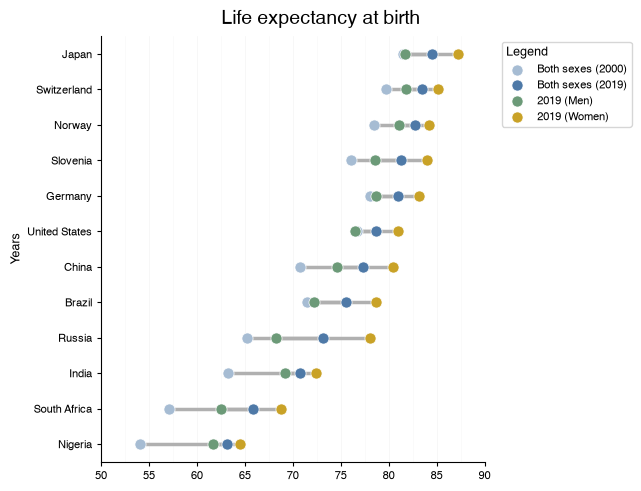

In [22]:
from datachart.utils import Panel

change = DumbbellChart(
    data=life,
    subtitle="Both sexes",
    start_name="2000",
    end_name="2019",
)
gap_2019 = DumbbellChart(
    data=[{"label": w["label"], "start": m["end"], "end": w["end"]} for w, m in zip(women, men)],
    subtitle="2019",
    start_name="Men",
    end_name="Women",
    style={"plot_dumbbell_start_color": "#6c9a78", "plot_dumbbell_end_color": "#c9a227"},
)

Panel(
    [change, gap_2019],
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

A grid keeps the charts apart, each in its own coordinate space, which suits two questions that share the data but not the axis: the change over two decades and the gap in the latest year.

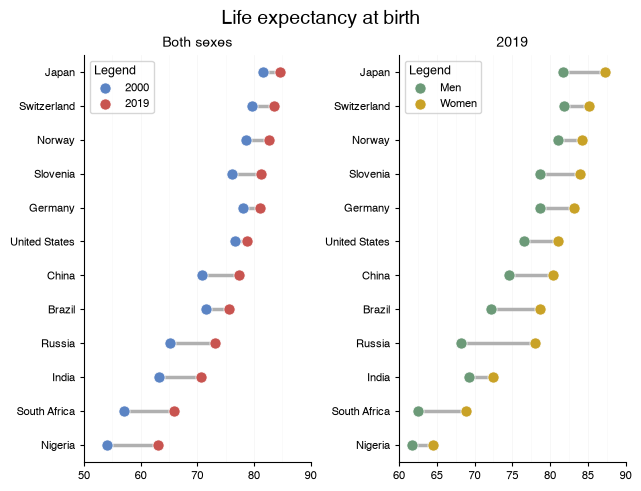

In [23]:
from datachart.utils import Grid

Grid(
    [[change, gap_2019]],
    title="Life expectancy at birth",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Additional Features

### Axis scales

A dumbbell encodes value by position, and a linear axis is the honest default. When the values span orders of magnitude, a logarithmic axis is what keeps the small categories readable: `scaley` takes a [SCALE](../../../references/constants/#datachart.constants.SCALE) member and applies to the value axis whichever way it runs. `populations`, defined in a hidden cell, holds the population of the twelve countries in 2000 and in 2024, in millions (source: the World Bank's World Development Indicators, indicator SP.POP.TOTL, rounded). On a linear axis Slovenia, Norway and Switzerland collapse into one dot at the left edge; on a log axis every country's change is visible, at the price that equal connector lengths now mean equal ratios, not equal differences.

In [24]:
# population in millions, 2000 and 2024 (World Bank WDI, SP.POP.TOTL, rounded)
POPULATION = {
    "India": (1057.9, 1450.9),
    "China": (1262.6, 1409.0),
    "United States": (282.2, 340.0),
    "Nigeria": (126.4, 232.7),
    "Brazil": (174.0, 212.0),
    "Russia": (146.6, 143.7),
    "Japan": (126.8, 124.0),
    "Germany": (82.2, 83.5),
    "South Africa": (47.2, 64.0),
    "Switzerland": (7.2, 9.0),
    "Norway": (4.5, 5.6),
    "Slovenia": (2.0, 2.1),
}
populations = [{"label": c, "start": s, "end": e} for c, (s, e) in POPULATION.items()]

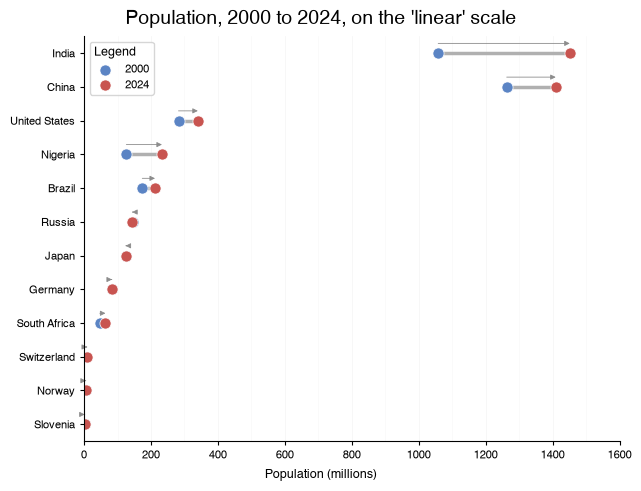

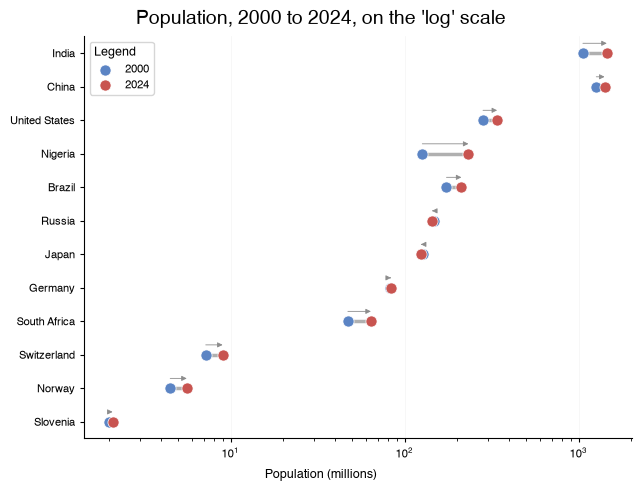

In [25]:
from datachart.constants import SCALE

for scale in [SCALE.LINEAR, SCALE.LOG]:
    DumbbellChart(
        data=populations,
        title=f"Population, 2000 to 2024, on the '{scale}' scale",
        xlabel="Population (millions)",
        figsize=FIG_SIZE.FULL_MEDIUM,
        start_name="2000",
        end_name="2024",
        show_direction=True,
        # the scale of the value axis
        scaley=scale,
    ).show()

### Themes

A theme sets the endpoint colors, the connector, the fonts and the dot edges of every chart at once, which is the way to restyle a whole document rather than one chart. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) as the [Themes](../../styling/themes/) guide shows; the [Theme Gallery](../../styling/theme-gallery/) shows every chart under each theme. The style is resolved when the chart is built, so the theme can be reset right after the call:

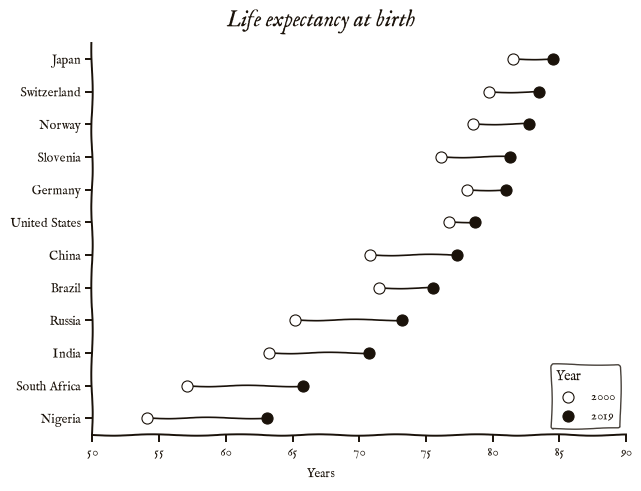

In [26]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.QUILL)
figure = DumbbellChart(
    data=life,
    title="Life expectancy at birth",
    xlabel="Years",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="2000",
    end_name="2019",
    legend={"title": "Year", "location": LEGEND_LOCATION.LOWER_RIGHT},
)
config.set_theme(THEME.DEFAULT)
figure.show()

## Real-World Examples

The examples below put the features above to work on real or realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: How Much Longer Do Women Live? (A Gap Sorted by Its Width, With Delta Labels and a Rule)

A dumbbell also shows a gap between two groups rather than a change over time. `gender_gap` runs each country from men's to women's life expectancy at birth in 2019, from the shared dataset (source: WHO Global Health Observatory). The question is how wide the gap is and where it is widest, so the rows are sorted by the delta, the delta is printed on every connector, and `emphasis_rule` highlights the gaps above six years and mutes the rest. Women outlive men in every one of these countries: by 2.8 years in Nigeria, by almost ten in Russia. A square and a circle tell the endpoints apart even in print.

In [27]:
# men's and women's life expectancy at birth in 2019 (WHO Global Health Observatory, rounded)
gender_gap = [
    {"label": country, "start": values[2][1], "end": values[1][1]}
    for country, values in LIFE.items()
]

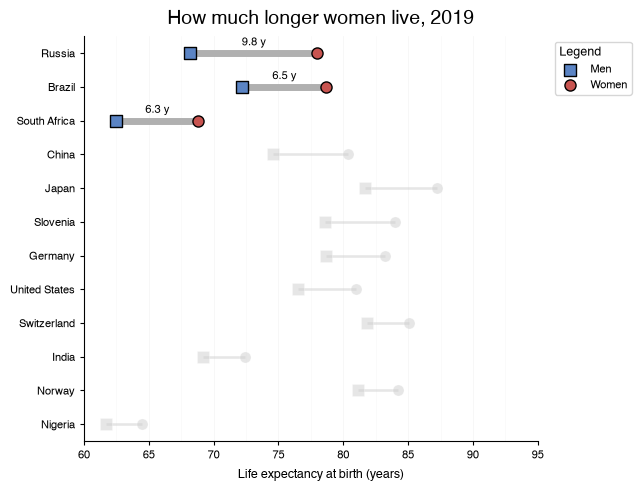

In [28]:
DumbbellChart(
    data=gender_gap,
    title="How much longer women live, 2019",
    xlabel="Life expectancy at birth (years)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="Men",
    end_name="Women",
    # widest gap first
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    # the width of each gap, in years
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:.1f} y",
    # the gaps above six years
    emphasis_rule={"above": 6},
    marker=(LINE_MARKER.SQUARE, LINE_MARKER.CIRCLE),
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Example 2: Did the Triage Redesign Cut the Waiting Time? (Before and After, With Direction Arrows, a Target Band and a Note)

`waits` holds the illustrative median waiting time, in minutes, of eight emergency departments in the quarter before and the quarter after a triage redesign. The question every intervention raises is whether it worked, and where: `show_direction` marks each row as a fall or a rise, the signed delta says by how much, `emphasis_rule` highlights the departments that cut their wait by more than fifteen minutes, a shaded band marks the 40-minute target, and a note points at the one department where the wait got longer. Sorted by the delta, the largest cut is at the top and the exception at the bottom.

In [29]:
# illustrative median waiting time in minutes, the quarter before and after a triage redesign
WAITS = [
    ("Central", 62, 41),
    ("Riverside", 55, 38),
    ("North", 48, 44),
    ("Harbour", 71, 47),
    ("Eastgate", 39, 36),
    ("Westfield", 44, 52),
    ("Hillside", 58, 35),
    ("Lakeview", 50, 30),
]
waits = [{"label": name, "start": before, "end": after} for name, before, after in WAITS]
TARGET = 40

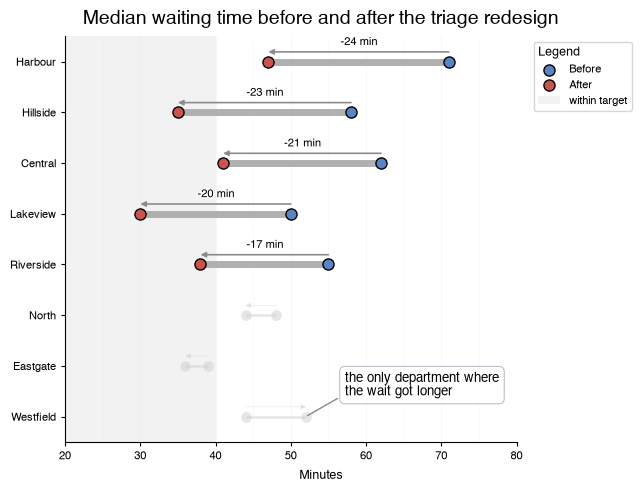

In [30]:
# the row of the one department whose wait got longer, once sorted by the change
by_change = sorted(waits, key=lambda record: record["end"] - record["start"])
worse = next(record for record in by_change if record["end"] > record["start"])
WORSE_ROW = by_change.index(worse)

DumbbellChart(
    data=waits,
    title="Median waiting time before and after the triage redesign",
    xlabel="Minutes",
    figsize=FIG_SIZE.FULL_MEDIUM,
    start_name="Before",
    end_name="After",
    # largest cut first
    sort=SORT.ASCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    # which way each department moved, and by how much
    show_direction=True,
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:+.0f} min",
    # the departments that cut more than fifteen minutes
    emphasis_rule={"below": -15},
    # the target band
    vspans={"xmin": 0, "xmax": TARGET, "label": "within target"},
    # the exception
    texts={
        "text": "the only department where\nthe wait got longer",
        "x": 0.62,
        "y": 0.14,
        "coords": "axes",
        "target": (worse["end"], WORSE_ROW),
    },
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    xmin=20,
    xmax=80,
).show()

### Example 3: Is the Gap Between Women and Men Closing? (Rises and Falls in Two Colors, and a Grid)

`narrowed` and `widened` hold the gap between women's and men's life expectancy in each country of the shared dataset, in years, in 2000 and in 2019 (source: WHO Global Health Observatory), split by whether the gap shrank or grew. A dumbbell chart draws one color pair per chart, so the split gives the two directions their own colors when the charts are overlaid; each chart sorts its own rows, and the first chart's rows come first, so the widened gaps lead and the narrowed ones follow, both ordered by the change. The gap narrowed in eight countries, most of all in Russia, and widened in four, all of them countries where women gained more years than men. The second chart of the grid shows those gains: `women` and `men` overlaid in the same row order, so each row of the top chart can be read against the two changes behind it.

In [31]:
# the gap between women's and men's life expectancy at birth, 2000 and 2019 (WHO GHO, rounded)
gap_change = [
    {"label": country, "start": round(values[1][0] - values[2][0], 1), "end": round(values[1][1] - values[2][1], 1)}
    for country, values in LIFE.items()
]
widened = [record for record in gap_change if record["end"] > record["start"]]
narrowed = [record for record in gap_change if record["end"] < record["start"]]

# the row order of the gap chart: widened first, then narrowed, each by the change
ORDER = [record["label"] for record in sorted(widened, key=lambda r: r["start"] - r["end"])]
ORDER += [record["label"] for record in sorted(narrowed, key=lambda r: r["start"] - r["end"])]
by_country = {sex: {record["label"]: record for record in data} for sex, data in [("women", women), ("men", men)]}
women_ordered = [by_country["women"][country] for country in ORDER]
men_ordered = [by_country["men"][country] for country in ORDER]

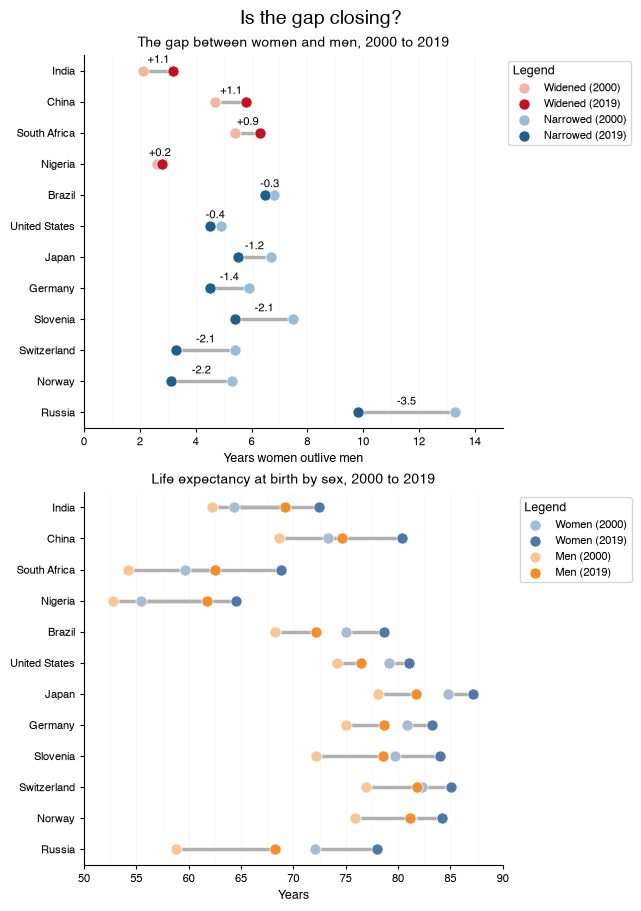

In [32]:
gap = DumbbellChart(
    # widened gaps first, narrowed gaps after, each chart in its own colors
    data=[widened, narrowed],
    subtitle=["Widened", "Narrowed"],
    style=[
        {"plot_dumbbell_start_color": "#f2b5a0", "plot_dumbbell_end_color": "#c1121f"},
        {"plot_dumbbell_start_color": "#9bbcd6", "plot_dumbbell_end_color": "#1f5f8b"},
    ],
    title="The gap between women and men, 2000 to 2019",
    xlabel="Years women outlive men",
    start_name="2000",
    end_name="2019",
    sort=SORT.DESCENDING,
    sort_by=DUMBBELL_SORT_KEY.DELTA,
    # the colors carry the direction, the labels the size
    show_values=True, value_kind=DUMBBELL_VALUE.DELTA,
    value_format="{:+.1f}",
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    xmin=0,
    xmax=15,
)
gains = DumbbellChart(
    # the same rows, in the same order
    data=[women_ordered, men_ordered],
    subtitle=["Women", "Men"],
    title="Life expectancy at birth by sex, 2000 to 2019",
    xlabel="Years",
    start_name="2000",
    end_name="2019",
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
)

Grid(
    [[gap], [gains]],
    title="Is the gap closing?",
    # taller than FIG_SIZE.FULL_TALL, so twelve labelled rows fit per chart
    figsize=(6.3, 9),
).show()